Intro & Problem:
The objective of this notebook is to build a Classification model to predict whether a bank customer will accept a personal loan offer (binary outcome y). By identifying the demographic and behavioral patterns of successful conversions, the bank can transition from expensive mass marketing to data-driven precision targeting, significantly improving their ROI on marketing campaigns.

In [1]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb

In [4]:
bank=pd.read_csv("bank.csv",sep=';')

In [5]:
bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
bank.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [9]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [10]:
bank.shape

(4521, 17)

In [7]:
bank.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

<Axes: xlabel='job', ylabel='count'>

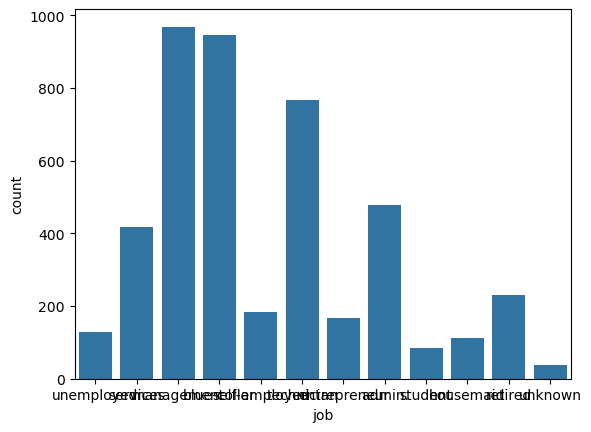

In [8]:
sb.countplot(x='job',data=bank)

In [13]:
bank_encoded=pd.get_dummies(bank,drop_first=True)

In [14]:
bank_encoded.dtypes

age                    int64
balance                int64
day                    int64
duration               int64
campaign               int64
pdays                  int64
previous               int64
job_blue-collar         bool
job_entrepreneur        bool
job_housemaid           bool
job_management          bool
job_retired             bool
job_self-employed       bool
job_services            bool
job_student             bool
job_technician          bool
job_unemployed          bool
job_unknown             bool
marital_married         bool
marital_single          bool
education_secondary     bool
education_tertiary      bool
education_unknown       bool
default_yes             bool
housing_yes             bool
loan_yes                bool
contact_telephone       bool
contact_unknown         bool
month_aug               bool
month_dec               bool
month_feb               bool
month_jan               bool
month_jul               bool
month_jun               bool
month_mar     

In [15]:
bank_encoded.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'y_yes'],
      dtype='object')

In [16]:
y=bank_encoded['y_yes']
X=bank_encoded.drop(columns='y_yes')

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3616
Testing samples: 905


In [18]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the model
# We set max_depth=5 so the tree doesn't get too complex and messy
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Train the model
model.fit(X_train, y_train)

# 3. Make predictions on the test set
predictions = model.predict(X_test)

Model Accuracy: 90.61%


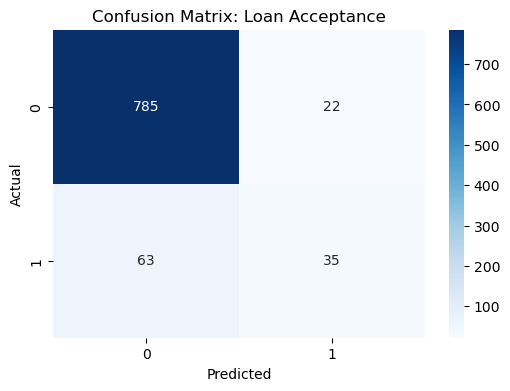


Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.97      0.95       807
        True       0.61      0.36      0.45        98

    accuracy                           0.91       905
   macro avg       0.77      0.66      0.70       905
weighted avg       0.89      0.91      0.89       905



In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Calculate Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 2. Confusion Matrix
# This shows: [True Negatives, False Positives]
#              [False Negatives, True Positives]
cm = confusion_matrix(y_test, predictions)

mp.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
mp.xlabel('Predicted')
mp.ylabel('Actual')
mp.title('Confusion Matrix: Loan Acceptance')
mp.show()

# 3. Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Conclusion and Key Insights:
The Decision Tree model provided clear business insights into customer behavior:

The "Duration" Effect: The most important predictor was the duration of the last contact. Longer conversations are the strongest indicator of customer interest.

Previous Success: Customers who responded positively to previous campaigns have a much higher probability of accepting a new offer.

Target Profile: The "ideal" customer group for this bank typically consists of individuals in management or retired roles with a positive previous contact history.